In [1]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Maternal__Child__and_Adolescent_Health_Needs_Assessment__2023-2024.csv")
df.head(5)

,Age_group,Sex,Topic,Data_source,Health_condition-Data_source,Period,Year,Denominator,Denominator_is,Number_with_outcome,...,Race_ethnicity,Rate_title,Trend_title,Filter_1000_or_more,Sort_1000_or_more,Primary_Neighborhood,Cause of death rank,Death_tooltip,Latest_data,Unique_row_id
0,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2019,2019.0,8307.0,TOTAL BIRTHS,25.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,5577
1,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2020,2020.0,7890.0,TOTAL BIRTHS,43.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,19728
2,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2021,2021.0,7413.0,TOTAL BIRTHS,46.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,21267
3,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2022,2022.0,7049.0,TOTAL BIRTHS,24.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,4433
4,0to12months,ALL,HEALTH CONDITION,CDPH BIRTH RECORDS,ASSISTED VENTILATION FOR >6 HOURS - CDPH BIRTH...,2014-2016,NaN,6673.0,TOTAL BIRTHS,21.0,...,ALL,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,Rate of ASSISTED VENTILATION FOR >6 HOURS - CD...,20-50,4,All,NaN,NaN,NaN,437


In [ ]:
#missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Age_group                           1
Sex                                 0
Topic                               1
Data_source                         0
Health_condition-Data_source        1
Period                              1
Year                            30635
Denominator                       188
Denominator_is                    120
Number_with_outcome               119
Numerator_is                       15
Rate_95CI                         148
Rate_SF_pop                       148
CI_low                            209
CI_high                           209
Rate_is                           124
Insurance                           1
Zip_code                            1
Race_ethnicity                      1
Rate_title                          1
Trend_title                        24
Filter_1000_or_more                 0
Sort_1000_or_more                   0
Primary_Neighborhood               10
Cause of death rank             62676
Death_tooltip                   6

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-1164486689.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipython-input-1164486689.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Year' in numerical_cols:
    numerical_cols.remove('Year')
    categorical_cols.append('Year')

column_data = {
    'Categorical Columns': pd.Series(categorical_cols),
    'Numerical Columns': pd.Series(numerical_cols)
}
column_table = pd.DataFrame(column_data)
display(column_table)

,Categorical Columns,Numerical Columns
0,Age_group,Denominator
1,Sex,Number_with_outcome
2,Topic,Rate_SF_pop
3,Data_source,CI_low
4,Health_condition-Data_source,CI_high
5,Period,Sort_1000_or_more
6,Denominator_is,Cause of death rank
7,Numerator_is,Latest_data
8,Rate_95CI,Unique_row_id
9,Rate_is,NaN


In [ ]:
print(column_table.iloc[:, :1])

             Categorical Columns
0                      Age_group
1                            Sex
2                          Topic
3                    Data_source
4   Health_condition-Data_source
5                         Period
6                 Denominator_is
7                   Numerator_is
8                      Rate_95CI
9                        Rate_is
10                     Insurance
11                      Zip_code
12                Race_ethnicity
13                    Rate_title
14                   Trend_title
15           Filter_1000_or_more
16          Primary_Neighborhood
17                 Death_tooltip
18                          Year


In [ ]:
#Detecting outliers using IQR method
import pandas as pd

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound))
outlier_count = outlier_mask.sum()
print("\nOutliers detected per column:\n", outlier_count)

df_clean = df[~outlier_mask.any(axis=1)]

print("\nBefore Cleaning:", df.shape)
print("After Cleaning:", df_clean.shape)

removed_pct = round((1 - len(df_clean) / len(df)) * 100, 2)
print(f"\nPercentage of rows removed: {removed_pct}%")


Outliers detected per column:
 Denominator            8392
Number_with_outcome    8475
Rate_SF_pop            6530
CI_low                 7377
CI_high                5584
Sort_1000_or_more         8
Cause of death rank      30
Latest_data               0
Unique_row_id             0
dtype: int64

Before Cleaning: (62714, 28)
After Cleaning: (43742, 28)

Percentage of rows removed: 30.25%


In [ ]:
df_clean.head()
df=df_clean

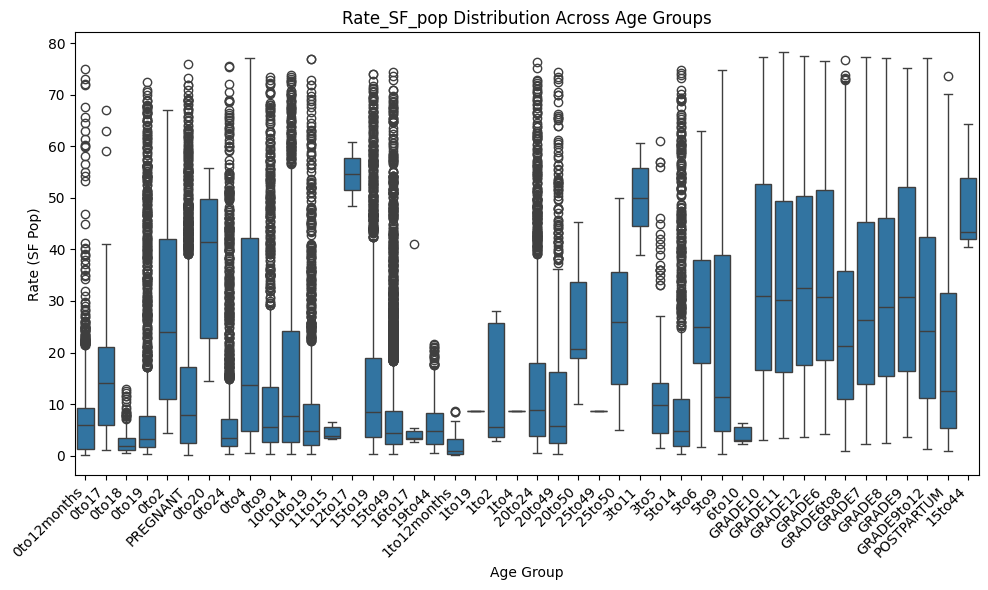

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(x='Age_group', y='Rate_SF_pop', data=df)
plt.title('Rate_SF_pop Distribution Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Rate (SF Pop)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3589530948.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




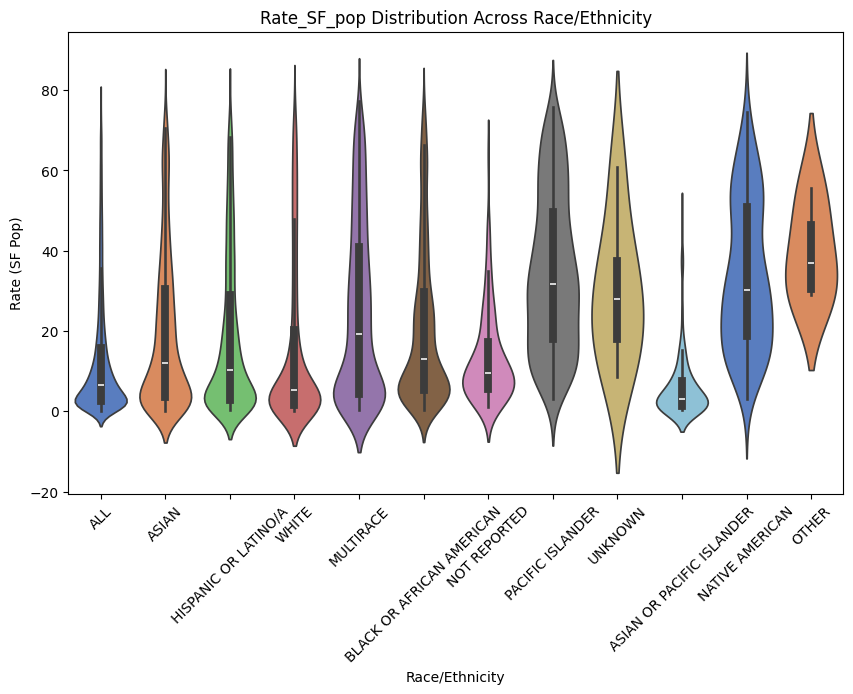

In [ ]:
plt.figure(figsize=(10,6))
sns.violinplot(x='Race_ethnicity', y='Rate_SF_pop', data=df, inner='box', palette='muted')
plt.title('Rate_SF_pop Distribution Across Race/Ethnicity')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Rate (SF Pop)')
plt.xticks(rotation=45)
plt.show()

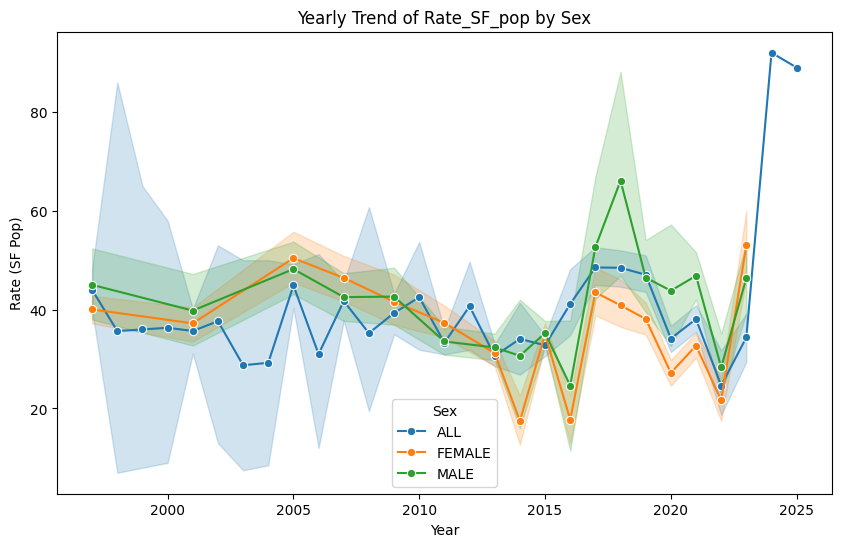

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Standardize the 'Sex' column (convert all values to uppercase)
df['Sex'] = df['Sex'].str.upper()

# Plot the cleaned data
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='Rate_SF_pop', hue='Sex', marker='o')
plt.title('Yearly Trend of Rate_SF_pop by Sex')
plt.xlabel('Year')
plt.ylabel('Rate (SF Pop)')
plt.show()


/tmp/ipython-input-4024880568.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




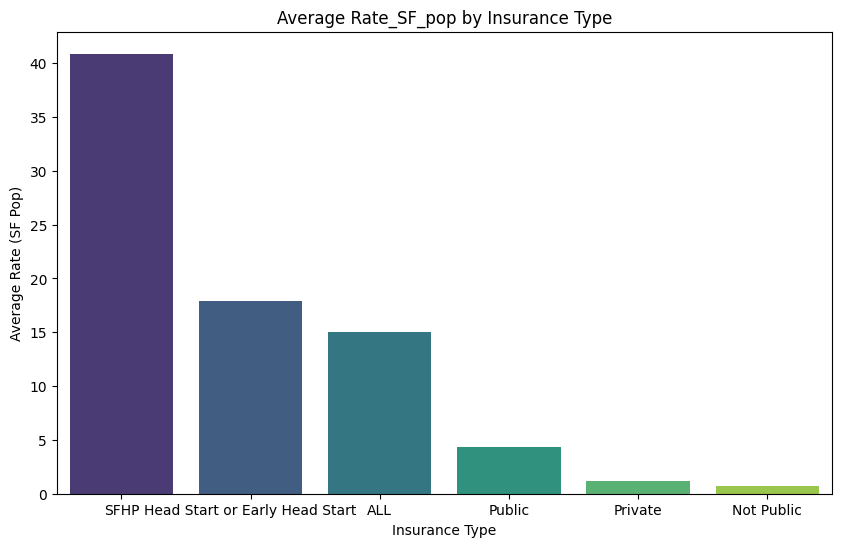

In [ ]:
plt.figure(figsize=(10,6))
insurance_avg = df.groupby('Insurance')['Rate_SF_pop'].mean().sort_values(ascending=False)
sns.barplot(x=insurance_avg.index, y=insurance_avg.values, palette='viridis')
plt.title('Average Rate_SF_pop by Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Average Rate (SF Pop)')
plt.show()


In [ ]:
!pip install pgeocode folium

In [ ]:
# Replace 'your_filename.csv' with a name you want
output_path = '/content/Visualization Data.csv'
df.to_csv(output_path, index=False)

print(f"✅ DataFrame saved to: {output_path}")


✅ DataFrame saved to: /content/Visualization Data.csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43742 entries, 0 to 62713
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age_group                     43742 non-null  object 
 1   Sex                           43742 non-null  object 
 2   Topic                         43742 non-null  object 
 3   Data_source                   43742 non-null  object 
 4   Health_condition-Data_source  43742 non-null  object 
 5   Period                        43742 non-null  object 
 6   Year                          43742 non-null  float64
 7   Denominator                   43742 non-null  float64
 8   Denominator_is                43742 non-null  object 
 9   Number_with_outcome           43742 non-null  float64
 10  Numerator_is                  43742 non-null  object 
 11  Rate_95CI                     43742 non-null  object 
 12  Rate_SF_pop                   43742 non-null  float64
 13  CI_low

In [ ]:
ß